# Example: Transcriptional Dynamics

The following applies minibatch and adaptive minibatch SMC ABC to the problem of estimating parameters from a transcriptional dynamics snapshot model of smFISH (single-molecule Fluorescent in situ Hybridization). The heterogeneity in these models is given by the shape (length L in this case) and transcription start site (z). The model is of bursty expression, following:


Will be filled out later

In [ ]:
## Import smc abc class and schemes
import smc_abc_schemes as schemes
import smc_abc_utils as utils
import numpy as np

from matplotlib import pyplot as plt

from numba import njit

#A class that generates smfish transcriptional dynamics snapshots
import transcriptional_dynamics as td

cwd appended to system path


## Constant Minibatch SMC ABC

In [2]:
#### Model parameters 
seed = 0
sample_size = 512
kplus = 30
kminus = 10
rburst = 10
diffusivity = 0.1

true_params = np.array([kplus,rburst,diffusivity])
num_params = true_params.shape[0]


T,dt = 5,0.01
bp,gp = 2,4
lengths = np.random.gamma(shape = gp, scale = 1/gp, size = (sample_size,))
sites = np.random.beta(a = bp,b = bp, size = (sample_size,)) * lengths

# homogeneous
#lengths = np.ones(shape = (sample_size,))
#sites = 0.5*lengths

length_index = np.arange(sample_size)
print(np.var(lengths), np.var(sites))


data_ = td.simulate(kplus, kminus, rburst, diffusivity, T, dt, sites, lengths)
#data = np.array([np.asarray(d) for d in data_],dtype=object)

data = [np.asarray(d) for d in data_]

#
def model(p,Bi):
    z = sites[Bi,]
    l = lengths[Bi,]
    obs_data = [data[i] for i in Bi]
    sim = td.simulate(p[0], kminus, p[1], p[2], T, dt, z, l)
    return sim, obs_data


#### Estimation parameters
## General
alpha = 0.5
num_particles = 500
num_sims = 5
cores = 4

## Prior
prior = utils.uniform_prior([[1,100],[1,100],[0,1.0]])

def rmsd(x):
    return np.sqrt(np.mean((x - np.mean(x))**2))
def stats_func_td_batch(x):
    counts = np.array([u.shape[0] for u in x])
    mean_counts = np.mean(counts)
    if np.sum(counts > 1) > 1:
        var_counts = np.var(counts)
        rmsd_list = np.empty(shape=(len(x),))
        for i,u in enumerate(x):
            if counts[i] > 1:
                rmsd_list[i] = rmsd(u)
            else:
                rmsd_list[i] = np.nan 
        #Nan mean
        mean_rmsd = np.nanmean(rmsd_list)
    else:
        var_counts = 0
        mean_rmsd = 0
    stats = np.array([mean_counts,var_counts,mean_rmsd])
    return stats

def stats_func_batch(x,y,sf = stats_func_td_batch):
    return sf(x),sf(y)


@njit
def stats_func_td(x):
    batch_size = len(x)
    out = np.zeros((batch_size, 3))
    
    # 1. Get counts
    for i in range(batch_size):
        # Using len() works for both fixed-shape and lists of arrays
        out[i, 0] = len(x[i])
    
    # 2. Vectorized mean of the first column
    m_counts = np.mean(out[:, 0])
    
    # 3. Variance influence and RMSD
    for i in range(batch_size):
        # Access the count we already stored
        out[i, 1] = (out[i, 0] - m_counts)**2
        
        # Numba handles np.std well
        if out[i, 0] >= 2:
            out[i, 2] = np.std(x[i])
        else:
            out[i, 2] = 0.0
            
    return out
def stats_func(x,y,sf = stats_func_td):
    return sf(x),sf(y)



## Distance function
dist_func = 'mahalanobis'


######## This makes a dictionary of information shared with the adaptive minibatch schemes
init_params = {
    'data':data,
    'model':model,
    'stats_func':stats_func,
    'prior':prior,
    'dist_func':dist_func,
    'num_particles':num_particles,
    'cores':cores,
    'alpha':alpha,
    'seed':seed
}
init_params_batch = init_params.copy()
init_params_batch.update({'stats_func':stats_func_batch})

0.24959342804817145 0.13100429867909627


Running benchmarks...
Batch 1: 0.000059 sec
Batch 2: 0.000105 sec
Batch 4: 0.000194 sec
Batch 8: 0.000384 sec
Batch 16: 0.000743 sec
Batch 32: 0.001484 sec
Batch 64: 0.002980 sec
Batch 128: 0.006582 sec
Batch 256: 0.013123 sec
Batch 512: 0.026254 sec
Average increase in seconds per sample: 4.830229916276746e-05


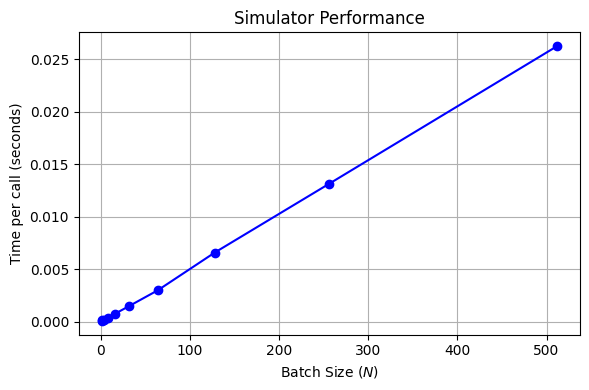

In [5]:
utils.benchmark_time([1,2,4,8,16,32,64,128,256,512],lambda n: stats_func_td(td.simulate(kplus, kminus, rburst, diffusivity, T, dt, sites[:n], lengths[:n])))

In [32]:
est = schemes.constant_init(init_params,[64])

while est.snr > 2.0:
    schemes.constant_loop(est)

Generation: 1. Batch Size: 64. Acceptance Rate: 1.000. Step time: 7.021. Total time 7.021. post-filter threshold: 13.0615. ESS: 500.00. Log HDPR vol: 8.701
Estimated v_total = 143.083. Noise: v/n = 2.236. Noise floor estimate: v/N = 0.279. Estimated c = 0.107. SNR: eps^2 / (v/n) = 76.310. Time per sim: 0.007
Generation: 2. Batch Size: 64. Acceptance Rate: 0.691. Step time: 7.075. Total time 14.096. post-filter threshold: 2.9935. ESS: 464.63. Log HDPR vol: 8.518
Estimated v_total = 16.210. Noise: v/n = 0.253. Noise floor estimate: v/N = 0.032. Estimated c = 0.157. SNR: eps^2 / (v/n) = 35.381. Time per sim: 0.005
Generation: 3. Batch Size: 64. Acceptance Rate: 0.500. Step time: 6.608. Total time 20.703. post-filter threshold: 1.6100. ESS: 463.81. Log HDPR vol: 8.144
Estimated v_total = 9.452. Noise: v/n = 0.148. Noise floor estimate: v/N = 0.018. Estimated c = 0.223. SNR: eps^2 / (v/n) = 17.550. Time per sim: 0.003
Generation: 4. Batch Size: 64. Acceptance Rate: 0.371. Step time: 6.500. 

In [9]:
est = schemes.fvc_init(init_params,[2,None,1.0])

while est.snr > 2.0:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.925. Total time 0.925. post-filter threshold: 6.7593. ESS: 500.00. Log HDPR vol: 8.839
Estimated v_total = 7.656. Noise: v/n = 3.828. Noise floor estimate: v/N = 0.015. Estimated c = 0.289. SNR: eps^2 / (v/n) = 11.936. Time per sim: 0.001
Automatic c selection: c = 0.2888833041530048
New hyperparameter set: [2, np.float64(0.2888833041530048), 1.0]
Estimated v_total with ema: 7.656. Batch size update: 2
Generation: 2. Batch Size: 2. Acceptance Rate: 0.595. Step time: 1.137. Total time 2.062. post-filter threshold: 2.6430. ESS: 464.22. Log HDPR vol: 8.739
Estimated v_total = 5.604. Noise: v/n = 2.802. Noise floor estimate: v/N = 0.011. Estimated c = 0.632. SNR: eps^2 / (v/n) = 2.493. Time per sim: 0.001
Estimated v_total with ema: 5.604. Batch size update: 9
Generation: 3. Batch Size: 9. Acceptance Rate: 0.316. Step time: 2.777. Total time 4.840. post-filter threshold: 1.6823. ESS: 468.69. Log HDPR vol: 8.591
Estimated v_

In [7]:
est = schemes.fvc_init(init_params,[2,None,1.0])

while (est.snr > 2.0) or (est.generation < 6):
    schemes.fvc_loop(est)
    est.batch_size = est.batch_size / 2

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.968. Total time 0.968. post-filter threshold: 7.9354. ESS: 500.00. Log HDPR vol: 8.835
Estimated v_total = 8.722. Noise: v/n = 4.361. Noise floor estimate: v/N = 0.017. Estimated c = 0.263. SNR: eps^2 / (v/n) = 14.439. Time per sim: 0.001
Automatic c selection: c = 0.26264852625348734
New hyperparameter set: [2, np.float64(0.26264852625348734), 1.0]
Estimated v_total with ema: 8.722. Batch size update: 2
Generation: 2. Batch Size: 2. Acceptance Rate: 0.626. Step time: 1.095. Total time 2.063. post-filter threshold: 2.7890. ESS: 472.59. Log HDPR vol: 8.747
Estimated v_total = 5.807. Noise: v/n = 2.903. Noise floor estimate: v/N = 0.011. Estimated c = 0.610. SNR: eps^2 / (v/n) = 2.679. Time per sim: 0.001
Estimated v_total with ema: 5.807. Batch size update: 11
Generation: 3. Batch Size: 4. Acceptance Rate: 0.353. Step time: 1.740. Total time 3.803. post-filter threshold: 1.7692. ESS: 464.18. Log HDPR vol: 8.748
Estimated

In [28]:
est = schemes.fvc_init(init_params,[2,0.1,1.0])

while est.snr > 2.0:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.926. Total time 0.926. post-filter threshold: 6.4777. ESS: 500.00. Log HDPR vol: 8.825
Estimated v_total = 7.924. Noise: v/n = 3.962. Noise floor estimate: v/N = 0.015. Estimated c = 0.307. SNR: eps^2 / (v/n) = 10.590. Time per sim: 0.001
Estimated v_total with ema: 7.924. Batch size update: 18
Generation: 2. Batch Size: 18. Acceptance Rate: 0.531. Step time: 3.506. Total time 4.431. post-filter threshold: 2.2951. ESS: 475.85. Log HDPR vol: 8.671
Estimated v_total = 9.422. Noise: v/n = 0.523. Noise floor estimate: v/N = 0.018. Estimated c = 0.310. SNR: eps^2 / (v/n) = 10.063. Time per sim: 0.002
Estimated v_total with ema: 9.422. Batch size update: 133
Generation: 3. Batch Size: 133. Acceptance Rate: 0.409. Step time: 15.500. Total time 19.931. post-filter threshold: 1.5003. ESS: 461.84. Log HDPR vol: 8.144
Estimated v_total = 9.660. Noise: v/n = 0.073. Noise floor estimate: v/N = 0.019. Estimated c = 0.155. SNR: eps^2 